# Seismic First-Break Project
## Step 1 - Data Exploration on Halfmile
## Goal: inspect the HDF5 structure without loading the whole dataset into RAM.

In [20]:
from pathlib import Path
import h5py
import json
import numpy as np
import matplotlib.pyplot as plt

In [2]:
PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "Halfmile3D_add_geom_sorted.hdf5"

print("Project root:", PROJECT_ROOT)
print("Data path:", DATA_PATH)
print("Exists:", DATA_PATH.exists())

Project root: c:\Users\HP\OneDrive\Desktop\seismic_project
Data path: c:\Users\HP\OneDrive\Desktop\seismic_project\data\raw\Halfmile3D_add_geom_sorted.hdf5
Exists: True


In [3]:
with h5py.File(DATA_PATH, "r") as f:
    print("Root keys:", list(f.keys()))
    print("TRACE_DATA keys:", list(f["TRACE_DATA"].keys()))
    print("DEFAULT keys:", list(f["TRACE_DATA/DEFAULT"].keys()))

Root keys: ['TRACE_DATA']
TRACE_DATA keys: ['DEFAULT']
DEFAULT keys: ['ALIAS_FREQ', 'ALIAS_SLOPE', 'AZIMUTH', 'CDP', 'CDPTRACE', 'CDP_X', 'CDP_Y', 'CHANNEL', 'COORD_SCALE', 'COORD_UNIT', 'CORR', 'CROSSLINE', 'DATA_START', 'DATA_STOP', 'DAY', 'DELAY', 'FIRST_BREAK_TIME', 'FTRACE', 'GAIN_TYPE', 'GAP_SIZE', 'HIGH_CUT_FREQ', 'HIGH_CUT_SLOPE', 'HORI_SUM', 'HOUR', 'HT_SCALE', 'INLINE', 'INSTR_GAIN_CONSTANT', 'INSTR_INIT_GAIN', 'INTERNAL_SORT1', 'INTERNAL_SORT2', 'LAG_TIME_A', 'LAG_TIME_B', 'LASTTR', 'LINE', 'LOW_CUT_FREQ', 'LOW_CUT_SLOPE', 'MINUTE', 'MODELLED_BREAK_TIME', 'NOTCH_FREQ', 'NOTCH_SLOPE', 'OFFSET', 'OFFSET_FLT', 'OVERTRAVEL', 'RECORDNUM', 'REC_DAT', 'REC_HT', 'REC_NUM_FIRST_FIELD', 'REC_NUM_LAST_FIELD', 'REC_NUM_POS1', 'REC_PEG', 'REC_PEG_DIST', 'REC_STATIC', 'REC_UPHOLE_TIME', 'REC_WATER', 'REC_X', 'REC_Y', 'REEL', 'REF_MODEL_REC_STATIC', 'REF_MODEL_SRC_STATIC', 'REF_RESID_REC_STATIC', 'REF_RESID_SRC_STATIC', 'REF_TOTAL_STATIC', 'REPEAT', 'SAMP_NUM', 'SAMP_RATE', 'SECOND', 'SHOT

In [4]:
with h5py.File(DATA_PATH, "r") as f:
    g = f["TRACE_DATA/DEFAULT"]

    print("data_array shape:", g["data_array"].shape)
    print("SHOTID shape:", g["SHOTID"].shape)
    print("SPARE1 shape:", g["SPARE1"].shape)
    print("REC_X shape:", g["REC_X"].shape)
    print("REC_Y shape:", g["REC_Y"].shape)

    print("SAMP_RATE first value:", g["SAMP_RATE"][0])
    print("SAMP_NUM first value:", g["SAMP_NUM"][0])
    print("COORD_SCALE first value:", g["COORD_SCALE"][0])
    print("HT_SCALE first value:", g["HT_SCALE"][0])

    print("First 10 SHOTIDs:", g["SHOTID"][:10])
    print("First 10 SPARE1 values:", g["SPARE1"][:10])

data_array shape: (1099559, 751)
SHOTID shape: (1099559, 1)
SPARE1 shape: (1099559, 1)
REC_X shape: (1099559, 1)
REC_Y shape: (1099559, 1)
SAMP_RATE first value: [2000]
SAMP_NUM first value: [751]
COORD_SCALE first value: [1]
HT_SCALE first value: [-10000]
First 10 SHOTIDs: [[20021449]
 [20021449]
 [20021449]
 [20021449]
 [20021449]
 [20021449]
 [20021449]
 [20021449]
 [20021449]
 [20021449]]
First 10 SPARE1 values: [[122]
 [127]
 [132]
 [137]
 [141]
 [146]
 [148]
 [151]
 [153]
 [156]]


In [5]:
with h5py.File(DATA_PATH, "r") as f:
    g = f["TRACE_DATA/DEFAULT"]

    shot_ids = g["SHOTID"][:, 0]
    spare1 = g["SPARE1"][:, 0]
    rec_x = g["REC_X"][:, 0]
    rec_y = g["REC_Y"][:, 0]

    print("shot_ids shape:", shot_ids.shape)
    print("spare1 shape:", spare1.shape)
    print("rec_x shape:", rec_x.shape)
    print("rec_y shape:", rec_y.shape)

    print("Unique shots:", len(np.unique(shot_ids)))
    print("Labeled traces (SPARE1 > 0):", np.sum(spare1 > 0))
    print("Unlabeled traces (SPARE1 <= 0):", np.sum(spare1 <= 0))

    print("SPARE1 min:", spare1.min())
    print("SPARE1 max:", spare1.max())

shot_ids shape: (1099559,)
spare1 shape: (1099559,)
rec_x shape: (1099559,)
rec_y shape: (1099559,)
Unique shots: 690
Labeled traces (SPARE1 > 0): 993189
Unlabeled traces (SPARE1 <= 0): 106370
SPARE1 min: -1
SPARE1 max: 1482


In [6]:
first_shot = shot_ids[0]
print("First shot:", first_shot)

First shot: 20021449


In [7]:
idx = np.where(shot_ids == first_shot)[0]

print("Number of traces in this shot:", len(idx))
print("First indices:", idx[:10])
print("Last indices:", idx[-10:])

Number of traces in this shot: 1578
First indices: [0 1 2 3 4 5 6 7 8 9]
Last indices: [1568 1569 1570 1571 1572 1573 1574 1575 1576 1577]


In [9]:
print("Is contiguous:", np.all(np.diff(idx) == 1))

Is contiguous: True


In [10]:
with h5py.File(DATA_PATH, "r") as f:
    g = f["TRACE_DATA/DEFAULT"]

    gather = g["data_array"][idx]
    labels = g["SPARE1"][idx, 0]

print("Gather shape:", gather.shape)
print("Labels shape:", labels.shape)

Gather shape: (1578, 751)
Labels shape: (1578,)


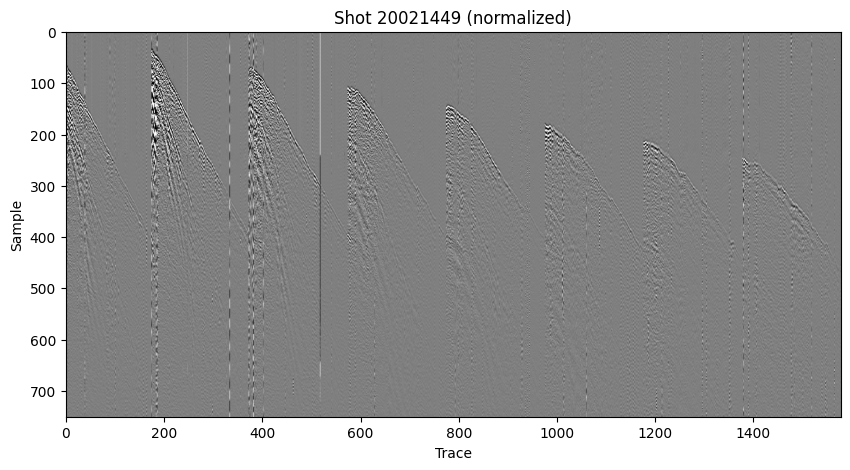

In [12]:
plt.figure(figsize=(10, 5))

# normalize
clip = np.percentile(np.abs(gather), 99)

plt.imshow(
    gather.T,
    aspect="auto",
    cmap="gray",
    vmin=-clip,
    vmax=clip
)

plt.title(f"Shot {first_shot} (normalized)")
plt.xlabel("Trace")
plt.ylabel("Sample")
plt.show()

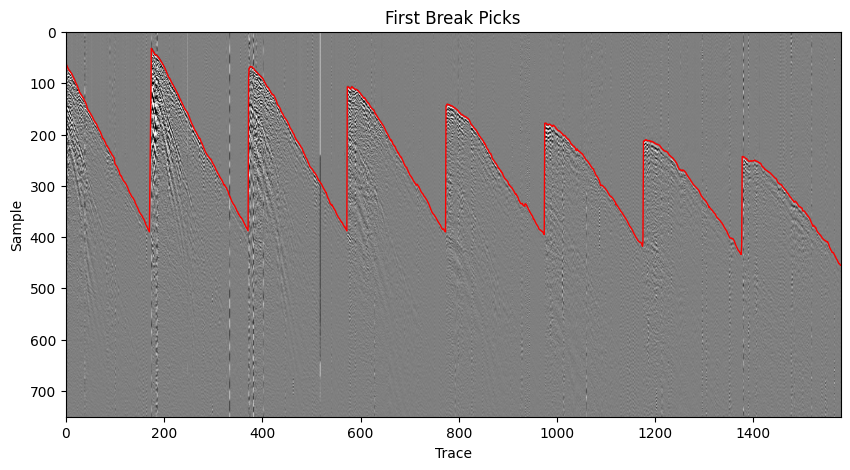

In [14]:
dt_ms = 2

pick_idx = (labels / dt_ms).astype(int)
valid = labels > 0

plt.figure(figsize=(10, 5))

plt.imshow(
    gather.T,
    aspect="auto",
    cmap="gray",
    vmin=-clip,
    vmax=clip
)

plt.plot(
    np.arange(len(pick_idx))[valid],
    pick_idx[valid],
    color="red",
    linewidth=1
)

plt.title("First Break Picks")
plt.xlabel("Trace")
plt.ylabel("Sample")
plt.show()

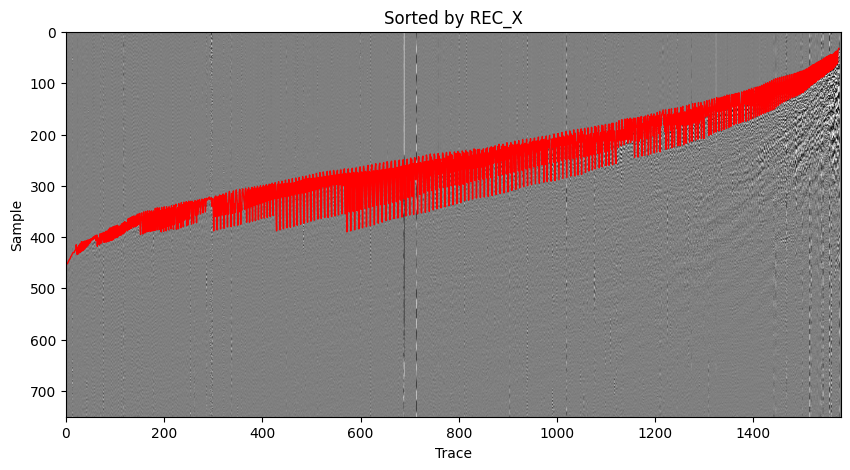

In [15]:
with h5py.File(DATA_PATH, "r") as f:
    g = f["TRACE_DATA/DEFAULT"]

    gather = g["data_array"][idx]
    labels = g["SPARE1"][idx, 0]
    rec_x = g["REC_X"][idx, 0]

# sort by receiver position
order = np.argsort(rec_x)

gather_sorted = gather[order]
labels_sorted = labels[order]

# convert labels
dt_ms = 2
pick_idx = (labels_sorted / dt_ms).astype(int)
valid = labels_sorted > 0

# plot
clip = np.percentile(np.abs(gather_sorted), 99)

plt.figure(figsize=(10, 5))

plt.imshow(
    gather_sorted.T,
    aspect="auto",
    cmap="gray",
    vmin=-clip,
    vmax=clip
)

plt.plot(
    np.arange(len(pick_idx))[valid],
    pick_idx[valid],
    color="red",
    linewidth=1
)

plt.title("Sorted by REC_X")
plt.xlabel("Trace")
plt.ylabel("Sample")
plt.show()

In [16]:
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed" / "Halfmile3D_add_geom_sorted"
MANIFEST_PATH = PROCESSED_DIR / "manifest.json"

print("Processed dir exists:", PROCESSED_DIR.exists())
print("Manifest exists:", MANIFEST_PATH.exists())

Processed dir exists: True
Manifest exists: True


In [21]:
with open(MANIFEST_PATH, "r", encoding="utf-8") as f:
    manifest = json.load(f)

print("Number of saved gathers:", len(manifest))
print("First item:", manifest[0])

Number of saved gathers: 690
First item: {'asset': 'Halfmile3D_add_geom_sorted', 'shot_index': 1, 'shot_id': 20021449, 'file': 'shot_0001_id_20021449.npz', 'n_traces': 1578, 'n_samples': 751, 'valid_labels': 1539, 'label_ratio': 0.9752851711026616}


In [22]:
sample_file = PROCESSED_DIR / manifest[0]["file"]
print(sample_file)
print(sample_file.exists())

c:\Users\HP\OneDrive\Desktop\seismic_project\data\processed\Halfmile3D_add_geom_sorted\shot_0001_id_20021449.npz
True


In [23]:
arr = np.load(sample_file)

print("Keys:", arr.files)
print("traces shape:", arr["traces"].shape)
print("labels_ms shape:", arr["labels_ms"].shape)
print("labels_sample shape:", arr["labels_sample"].shape)
print("rec_x shape:", arr["rec_x"].shape)
print("shot_id:", arr["shot_id"][0])
print("samp_rate_us:", arr["samp_rate_us"][0])

Keys: ['traces', 'labels_ms', 'labels_sample', 'rec_x', 'rec_y', 'shot_id', 'samp_rate_us', 'samp_num']
traces shape: (1578, 751)
labels_ms shape: (1578,)
labels_sample shape: (1578,)
rec_x shape: (1578,)
shot_id: 20021449
samp_rate_us: 2000.0


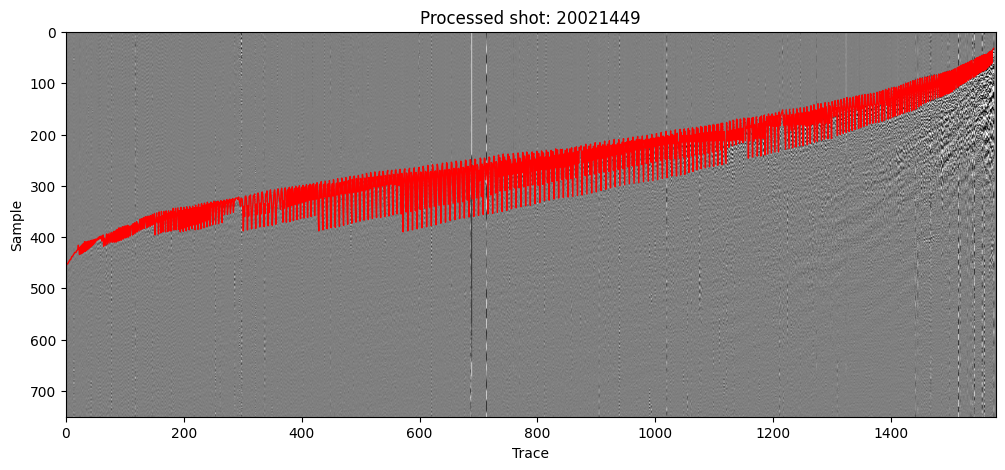

In [24]:
traces = arr["traces"]
labels_sample = arr["labels_sample"]

valid = labels_sample >= 0
clip = np.percentile(np.abs(traces), 99)

plt.figure(figsize=(12, 5))
plt.imshow(
    traces.T,
    aspect="auto",
    cmap="gray",
    vmin=-clip,
    vmax=clip
)

plt.plot(
    np.arange(len(labels_sample))[valid],
    labels_sample[valid],
    color="red",
    linewidth=1
)

plt.title(f"Processed shot: {arr['shot_id'][0]}")
plt.xlabel("Trace")
plt.ylabel("Sample")
plt.show()

In [48]:
from src.first_break_window_dataset import FirstBreakWindowDataset
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

In [49]:
TRAIN_CSV = PROJECT_ROOT / "data" / "splits" / "train_shots.csv"
VAL_CSV = PROJECT_ROOT / "data" / "splits" / "val_shots.csv"
TEST_CSV = PROJECT_ROOT / "data" / "splits" / "test_shots.csv"

train_win_ds = FirstBreakWindowDataset(TRAIN_CSV, window_width=256, stride=128)
val_win_ds = FirstBreakWindowDataset(VAL_CSV, window_width=256, stride=128)
test_win_ds = FirstBreakWindowDataset(TEST_CSV, window_width=256, stride=128)

print("train windows:", len(train_win_ds))
print("val windows:", len(val_win_ds))
print("test windows:", len(test_win_ds))

train windows: 42858
val windows: 18062
test windows: 9581


In [50]:
sample = train_win_ds[0]

print("asset:", sample["asset"])
print("shot_id:", sample["shot_id"])
print("image shape:", sample["image"].shape)
print("mask shape:", sample["mask"].shape)
print("valid_width:", sample["valid_width"])
print("window_start:", sample["window_start"])
print("window_end:", sample["window_end"])

asset: Brunswick_orig_1500ms_V2_(1)
shot_id: 1
image shape: torch.Size([1, 751, 256])
mask shape: torch.Size([1, 751, 256])
valid_width: 256
window_start: 0
window_end: 256


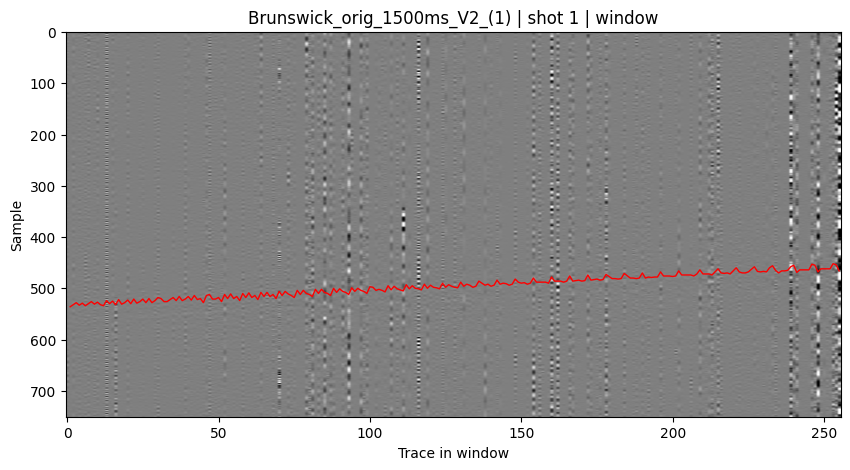

In [51]:
image = sample["image"][0].numpy()
labels = sample["labels_sample"].numpy()
valid = labels >= 0

plt.figure(figsize=(10, 5))
plt.imshow(image, aspect="auto", cmap="gray", vmin=-1, vmax=1)
plt.plot(
    np.arange(len(labels))[valid],
    labels[valid],
    color="red",
    linewidth=1
)
plt.title(f'{sample["asset"]} | shot {sample["shot_id"]} | window')
plt.xlabel("Trace in window")
plt.ylabel("Sample")
plt.show()

In [52]:
train_loader = DataLoader(
    train_win_ds,
    batch_size=2,
    shuffle=True,
    num_workers=0,
)

batch = next(iter(train_loader))

print("batch image shape:", batch["image"].shape)
print("batch mask shape:", batch["mask"].shape)

batch image shape: torch.Size([2, 1, 751, 256])
batch mask shape: torch.Size([2, 1, 751, 256])


In [53]:
import torch
from src.tiny_unet import TinyUNet

In [54]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

model = TinyUNet(in_channels=1, out_channels=1, base_ch=8).to(device)
print(model.__class__.__name__)

device: cpu
TinyUNet


In [55]:
batch = next(iter(train_loader))

x = batch["image"].to(device)   # (B, 1, 751, 256)
y = batch["mask"].to(device)    # (B, 1, 751, 256)

with torch.no_grad():
    logits = model(x)

print("input shape :", x.shape)
print("target shape:", y.shape)
print("logits shape:", logits.shape)

input shape : torch.Size([2, 1, 751, 256])
target shape: torch.Size([2, 1, 751, 256])
logits shape: torch.Size([2, 1, 751, 256])


In [56]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader, Subset

from src.first_break_window_dataset import FirstBreakWindowDataset
from src.tiny_unet import TinyUNet
from src.train_utils import train_model, extract_pick_samples_from_logits

In [57]:
TRAIN_CSV = PROJECT_ROOT / "data" / "splits" / "train_shots.csv"
VAL_CSV = PROJECT_ROOT / "data" / "splits" / "val_shots.csv"
TEST_CSV = PROJECT_ROOT / "data" / "splits" / "test_shots.csv"

train_win_ds = FirstBreakWindowDataset(TRAIN_CSV, window_width=256, stride=128)
val_win_ds = FirstBreakWindowDataset(VAL_CSV, window_width=256, stride=128)
test_win_ds = FirstBreakWindowDataset(TEST_CSV, window_width=256, stride=128)

print("train windows:", len(train_win_ds))
print("val windows:", len(val_win_ds))
print("test windows:", len(test_win_ds))

train windows: 42858
val windows: 18062
test windows: 9581


In [58]:
train_subset_idx = list(range(0, min(1000, len(train_win_ds))))
val_subset_idx = list(range(0, min(300, len(val_win_ds))))

train_small = Subset(train_win_ds, train_subset_idx)
val_small = Subset(val_win_ds, val_subset_idx)

print("train small:", len(train_small))
print("val small:", len(val_small))

train small: 1000
val small: 300


In [59]:
train_loader_small = DataLoader(
    train_small,
    batch_size=2,
    shuffle=True,
    num_workers=0,
)

val_loader_small = DataLoader(
    val_small,
    batch_size=2,
    shuffle=False,
    num_workers=0,
)

In [60]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

model = TinyUNet(in_channels=1, out_channels=1, base_ch=8).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

device: cpu


In [61]:
history_small, best_state_small = train_model(
    model=model,
    train_loader=train_loader_small,
    val_loader=val_loader_small,
    optimizer=optimizer,
    device=device,
    epochs=3,
)

Epoch 01 | train_loss=0.6025 | train_mae=79.79 | val_loss=0.4394 | val_mae=43.72 | time=464.0s
Epoch 02 | train_loss=0.3808 | train_mae=32.38 | val_loss=0.3600 | val_mae=20.13 | time=449.1s
Epoch 03 | train_loss=0.2923 | train_mae=20.67 | val_loss=0.3512 | val_mae=19.49 | time=452.6s


In [62]:
history_small

[{'epoch': 1,
  'train_loss': 0.6025004670619964,
  'train_mae_samples': 79.78916240310669,
  'val_loss': 0.4394282251596451,
  'val_mae_samples': 43.72372299194336,
  'epoch_time_sec': 463.98350071907043},
 {'epoch': 2,
  'train_loss': 0.3807590636014938,
  'train_mae_samples': 32.384818587779996,
  'val_loss': 0.35998818576335906,
  'val_mae_samples': 20.130657877922058,
  'epoch_time_sec': 449.07206320762634},
 {'epoch': 3,
  'train_loss': 0.2923018141686916,
  'train_mae_samples': 20.665280055046082,
  'val_loss': 0.35119814892609913,
  'val_mae_samples': 19.486901527245838,
  'epoch_time_sec': 452.6035623550415}]

In [63]:
model.load_state_dict(best_state_small)
model.eval()

TinyUNet(
  (inc): DoubleConv(
    (block): Sequential(
      (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (down1): Down(
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (conv): DoubleConv(
      (block): Sequential(
        (0): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(16, eps=1e-05, momentum=0.1, affin

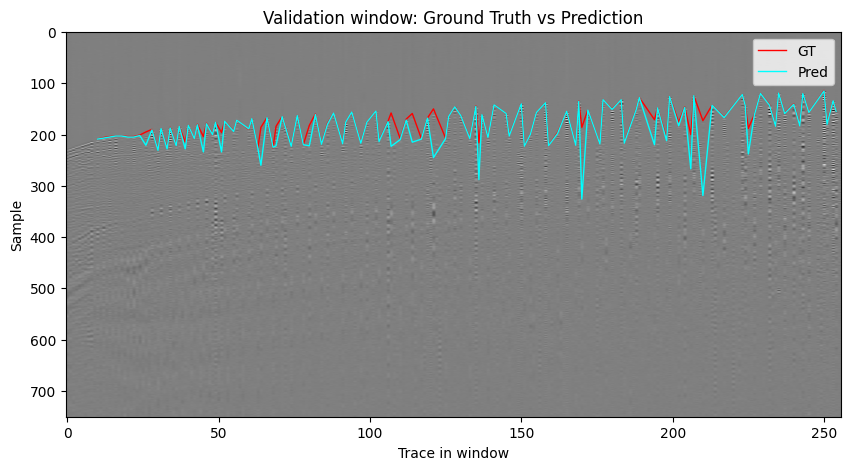

In [64]:
batch = next(iter(val_loader_small))

image = batch["image"].to(device).float()
labels_sample = batch["labels_sample"].to(device).long()
trace_valid_mask = batch["trace_valid_mask"].to(device).float()

with torch.no_grad():
    logits = model(image)

pred_idx = extract_pick_samples_from_logits(logits)[0].cpu().numpy()

img = image[0, 0].cpu().numpy()
gt = labels_sample[0].cpu().numpy()
valid = (gt >= 0) & (trace_valid_mask[0].cpu().numpy() > 0)

plt.figure(figsize=(10, 5))
plt.imshow(img, aspect="auto", cmap="gray", vmin=-1, vmax=1)
plt.plot(np.arange(len(gt))[valid], gt[valid], color="red", linewidth=1, label="GT")
plt.plot(np.arange(len(pred_idx))[valid], pred_idx[valid], color="cyan", linewidth=1, label="Pred")
plt.title("Validation window: Ground Truth vs Prediction")
plt.xlabel("Trace in window")
plt.ylabel("Sample")
plt.legend()
plt.show()